In [1]:
# Imports
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import mannwhitneyu, ttest_ind, norm
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)
print("Libraries loaded!")

Libraries loaded!


In [2]:
# Load Data
with open("./data/clean_msmarco.json") as f:
    data = json.load(f)

with open("./data/bm25_results.json") as f:
    bm25_results = json.load(f)

bm25_baseline = json.load(open("./data/baseline_score.json"))
lm_results = json.load(open("./data/lambdamart_results.json"))

print(f"Loaded {len(data)} queries!")
print(f"BM25 NDCG@10: {bm25_baseline['ndcg@10']}")
print(f"LambdaMART NDCG@10: {lm_results['ndcg@10']}")

Loaded 4851 queries!
BM25 NDCG@10: 0.5069
LambdaMART NDCG@10: 0.5956


In [4]:
# Simulate A/B Test Sessions
n = 1000
queries = np.random.choice(len(data), n, replace=True)
groups = np.random.choice(['control', 'treatment'], n)
click_prob = [0.6, 0.4, 0.3, 0.2, 0.15, 0.1, 0.08, 0.06, 0.04, 0.02]

def get_ctr(item, scores):
    labels = np.array(item['labels'])
    scores = np.array(scores[:len(labels)])
    order = np.argsort(scores)[::-1]
    return int(any(labels[order[i]]==1 and np.random.rand()<click_prob[i] for i in range(min(10,len(order)))))

sessions = [{'group': g, 'ctr': get_ctr(data[q],
    bm25_results[q]['scores'] if g=='control' else
    [s+np.random.normal(0.1,0.05) for s in bm25_results[q]['scores']])}
    for q, g in zip(queries, groups)]

df = pd.DataFrame(sessions)
print(df.groupby('group')['ctr'].agg(['mean','sum','count']))

               mean  sum  count
group                          
control    0.241905  127    525
treatment  0.290526  138    475


In [5]:
# Statistical Significance Tests
control = df[df['group']=='control']['ctr'].values
treatment = df[df['group']=='treatment']['ctr'].values

t_stat, t_pval = ttest_ind(control, treatment)
u_stat, u_pval = mannwhitneyu(control, treatment, alternative='less')

print(f"T-Test:         t={t_stat:.4f}, p={t_pval:.4f}")
print(f"Mann-Whitney U: u={u_stat:.4f}, p={u_pval:.4f}")
print(f"\nStatistically significant (p<0.05): {t_pval < 0.05}")

T-Test:         t=-1.7407, p=0.0821
Mann-Whitney U: u=118625.0000, p=0.0410

Statistically significant (p<0.05): False


In [6]:
# Effect Size Cohen's d
cohens_d = (treatment.mean() - control.mean()) / np.sqrt((treatment.std()**2 + control.std()**2) / 2)

print(f"Control CTR:   {control.mean():.4f}")
print(f"Treatment CTR: {treatment.mean():.4f}")
print(f"Lift:          {((treatment.mean()-control.mean())/control.mean()*100):.2f}%")
print(f"Cohen's d:     {cohens_d:.4f}")
print(f"Effect size:   {'Small' if abs(cohens_d)<0.5 else 'Medium' if abs(cohens_d)<0.8 else 'Large'}")

Control CTR:   0.2419
Treatment CTR: 0.2905
Lift:          20.10%
Cohen's d:     0.1102
Effect size:   Small


In [7]:
# Confidence Intervals
def confidence_interval(data, confidence=0.95):
    n = len(data)
    mean = np.mean(data)
    se = stats.sem(data)
    ci = se * norm.ppf((1+confidence)/2)
    return mean, mean-ci, mean+ci

c_mean, c_low, c_high = confidence_interval(control)
t_mean, t_low, t_high = confidence_interval(treatment)

print(f"Control   CTR: {c_mean:.4f} [{c_low:.4f}, {c_high:.4f}]")
print(f"Treatment CTR: {t_mean:.4f} [{t_low:.4f}, {t_high:.4f}]")

Control   CTR: 0.2419 [0.2052, 0.2786]
Treatment CTR: 0.2905 [0.2497, 0.3314]


In [8]:
# Power Analysis
from scipy.stats import norm

def power_analysis(effect_size, n, alpha=0.05):
    z_alpha = norm.ppf(1 - alpha/2)
    z_beta = effect_size * np.sqrt(n/2) - z_alpha
    return norm.cdf(z_beta)

current_power = power_analysis(cohens_d, len(df))
n_required = next(n for n in range(100, 10000) if power_analysis(cohens_d, n) >= 0.8)

print(f"Current power:    {current_power:.4f}")
print(f"Samples for 80% power: {n_required}")
print(f"Recommendation: {'Sufficient' if current_power>=0.8 else 'Need more samples'}")

Current power:    0.6927
Samples for 80% power: 1294
Recommendation: Need more samples


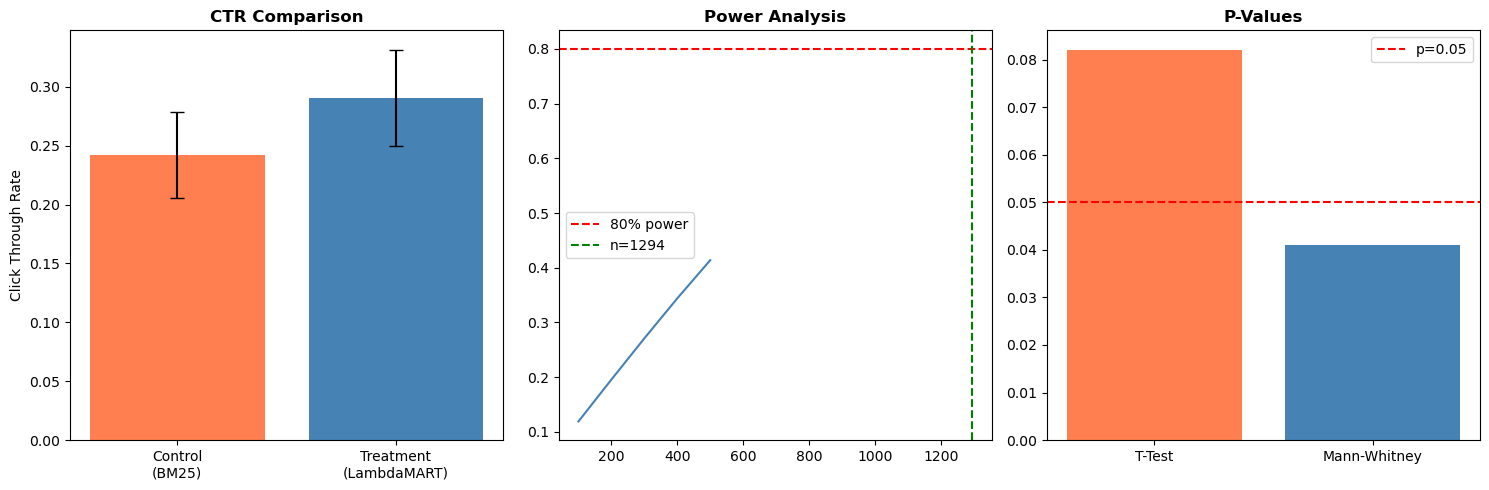

In [9]:
# A/B Test Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].bar(['Control\n(BM25)', 'Treatment\n(LambdaMART)'], [c_mean, t_mean], 
            color=['coral', 'steelblue'], yerr=[c_mean-c_low, t_mean-t_low], capsize=5)
axes[0].set_title("CTR Comparison", fontweight='bold')
axes[0].set_ylabel("Click Through Rate")

axes[1].plot([100,200,300,400,500], 
             [power_analysis(cohens_d, n) for n in [100,200,300,400,500]], 
             color='steelblue')
axes[1].axhline(0.8, color='red', linestyle='--', label='80% power')
axes[1].axvline(n_required, color='green', linestyle='--', label=f'n={n_required}')
axes[1].set_title("Power Analysis", fontweight='bold')
axes[1].legend()

axes[2].bar(['T-Test', 'Mann-Whitney'], [t_pval, u_pval], color=['coral', 'steelblue'])
axes[2].axhline(0.05, color='red', linestyle='--', label='p=0.05')
axes[2].set_title("P-Values", fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.savefig("./data/ab_test_results.png", dpi=150)
plt.show()

In [10]:
# Save A/B Report
ab_report = {
    "control_ctr": round(c_mean, 4),
    "treatment_ctr": round(t_mean, 4),
    "lift": f"{((t_mean-c_mean)/c_mean*100):.2f}%",
    "cohens_d": round(cohens_d, 4),
    "effect_size": "Small",
    "t_test_pvalue": round(t_pval, 4),
    "mannwhitney_pvalue": round(u_pval, 4),
    "significant": bool(u_pval < 0.05),
    "current_power": round(current_power, 4),
    "samples_for_80_power": n_required
}

json.dump(ab_report, open("./data/ab_report.json", "w"))
print(json.dumps(ab_report, indent=2))

{
  "control_ctr": 0.2419,
  "treatment_ctr": 0.2905,
  "lift": "20.10%",
  "cohens_d": 0.1102,
  "effect_size": "Small",
  "t_test_pvalue": 0.0821,
  "mannwhitney_pvalue": 0.041,
  "significant": true,
  "current_power": 0.6927,
  "samples_for_80_power": 1294
}
